In [1]:
import copy

import torch
import torch.nn as nn
import torchvision
import numpy as np
from matplotlib import pyplot as plt

from experiment_thesis.dataset_preperation.transformation import get_transformation_sequence_images
from search.parallel_gradient import ParallelGradientDescent
from utils.sampling import BatchNegativeSampler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#look for experiment files in parents
import os

path_found = False
current_path = os.getcwd()
while not path_found:
    if os.path.exists(os.path.join(current_path, "experiment_files")):
        path_found = True
        break
    current_path = os.path.dirname(current_path)

experiment_files_path_data = os.path.join(current_path, "experiment_files", "data")
dataset ="mnist"# "bigger_emnist"
architecture ="resnet_small"# "bigger_extended_resnet_small"
budget = 120

In [2]:
from experiment_thesis.dataset_preperation.get_dataset import get_dataset_info,get_dataset

dataset_info = get_dataset_info(dataset)
dataset_dict = get_dataset(dataset_info,path=experiment_files_path_data, batch_size=dataset_info.batch_size)
transform_name = dataset_info.transform_seq_name

In [3]:


dataset_dict.keys()
dataset_train = dataset_dict['train_dataset']
dataset_val = dataset_dict['val_dataset']
dataset_test = dataset_dict['test_dataset']
train_loader = dataset_dict['train_loader']
val_loader = dataset_dict['val_loader']
test_loader = dataset_dict['test_loader']
n_classes = dataset_info.num_classes
train_loader_transformed = dataset_dict['train_loader_transformed']
val_loader_transformed = dataset_dict['val_loader_transformed']
test_loader_transformed = dataset_dict['test_loader_transformed']
train_loader_no_shuffle = dataset_dict['train_loader_no_shuffle']

In [4]:
batch_size = next(iter(train_loader))[0].shape[0]


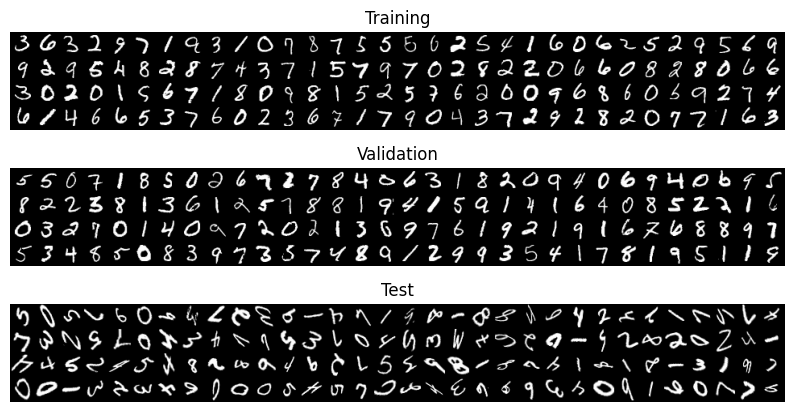

In [5]:
from utils.eval.vis import vis_dataset

vis_dataset(train_loader,val_loader,test_loader_transformed)

In [6]:
from experiment_thesis.main import train_and_get_model,train_or_load_energy_model
from experiment_thesis.dataset_preperation.basic_networks import get_network
from utils.eval.main_model import evaluate_base_model

model_dir_path = os.path.join(current_path, "experiment_files", "models")
embedding_cache_path = os.path.join(current_path, "experiment_files", "embedding_cache")
# Add results dir and helper for save paths
results_dir_path = os.path.join(current_path, "experiment_files", "results", dataset, architecture, "comparision_over_budget")
os.makedirs(results_dir_path, exist_ok=True)


def savepath(label: str) -> str:
    safe = "".join(c if c.isalnum() or c in "-_." else "_" for c in label)
    return os.path.join(results_dir_path,transform_name, f"{safe}.json")

C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
model = get_network(dataset_info,architecture, num_classes=n_classes).to(device)
modelname = f"{dataset}_{architecture}"
cache_name_train= f"{dataset}_{architecture}_embedding_cache_train"

train_and_get_model(model,model_dir_path,modelname, train_loader, val_loader , trainer_kwargs= {
        "accelerator": "auto",
        "max_epochs": dataset_info.epochs,
        "precision": "16-mixed",
},load_if_exists=True)



Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\mnist_resnet_small.safetensors


(FlexibleResNet(
   (stem_conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
   (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   (stem_act): GELU(approximate='none')
   (stages): ModuleList(
     (0): Sequential(
       (0): BasicBlock(
         (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (act): GELU(approximate='none')
       )
     )
     (1): Sequential(
       (0): BasicBlock(
         (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
         (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    

In [8]:
from embedding_cache import LayerEmbeddingCache



cache_name_train = f"{dataset}_{architecture}_{transform_name}_embedding_cache_train"

from torch.utils.data import SequentialSampler
import embedding_cache
import importlib
importlib.reload(embedding_cache)
from embedding_cache import LayerEmbeddingCache
from confidence.input_transform import RandomProjectionModule


transform_name = dataset_info.transform_seq_name

cache_name_train = f"{dataset}_{architecture}_{transform_name}_embedding_cache_train3x3"

reducer_names = ["rp", "sparse_rp", "image_transform"]
reducer_kwargs = [
    {"n_components": 1024, "method": "gaussian"},
    {"n_components": 1024, "density": "auto"},
    {"reduce_dims": (3, 3), "rp_dim":1024}  # adjust as needed for your image shape
]
reducer_dim_threshold = [
    (4096, 50000),      # Random projection for 4096–50,000
    (4096, 300000),    # Sparse random for 50,001–300,000
    (4096, None)      # Image transform for >300,000
]

train_cache = LayerEmbeddingCache(
    model,
    train_loader_no_shuffle,
    cache_dir=os.path.join(embedding_cache_path, cache_name_train),
    reducer_name=reducer_names,
    reducer_kwargs=reducer_kwargs,
    reducer_fit_batches=0,
    reducer_dim_threshold=reducer_dim_threshold
)

In [9]:
from embedding_cache import LayerEmbeddingCache



cache_name_train = f"{dataset}_{architecture}_{transform_name}_embedding_cache_train"

from torch.utils.data import SequentialSampler
import embedding_cache
import importlib
importlib.reload(embedding_cache)
from embedding_cache import LayerEmbeddingCache
from confidence.input_transform import RandomProjectionModule


transform_name = dataset_info.transform_seq_name

cache_name_train = f"{dataset}_{architecture}_{transform_name}_embedding_cache_train2x2"

reducer_names = ["rp", "sparse_rp", "image_transform"]
reducer_kwargs = [
    {"n_components": 1024, "method": "gaussian"},
    {"n_components": 1024, "density": "auto"},
    {"reduce_dims": (2, 2), "rp_dim":1024}  # adjust as needed for your image shape
]
reducer_dim_threshold = [
    (4096, 50000),      # Random projection for 4096–50,000
    (4096, 300000),    # Sparse random for 50,001–300,000
    (4096, None)      # Image transform for >300,000
]

train_cache2 = LayerEmbeddingCache(
    model,
    train_loader_no_shuffle,
    cache_dir=os.path.join(embedding_cache_path, cache_name_train),
    reducer_name=reducer_names,
    reducer_kwargs=reducer_kwargs,
    reducer_fit_batches=0,
    reducer_dim_threshold=reducer_dim_threshold
)

In [10]:
from embedding_cache import LayerEmbeddingCache



cache_name_train = f"{dataset}_{architecture}_{transform_name}_embedding_cache_train"

from torch.utils.data import SequentialSampler
import embedding_cache
import importlib
importlib.reload(embedding_cache)
from embedding_cache import LayerEmbeddingCache
from confidence.input_transform import RandomProjectionModule


transform_name = dataset_info.transform_seq_name

cache_name_train = f"{dataset}_{architecture}_{transform_name}_embedding_cache_train4x4"

reducer_names = ["rp", "sparse_rp", "image_transform"]
reducer_kwargs = [
    {"n_components": 1024, "method": "gaussian"},
    {"n_components": 1024, "density": "auto"},
    {"reduce_dims": (4, 4), "rp_dim":1024}  # adjust as needed for your image shape
]
reducer_dim_threshold = [
    (4096, 50000),      # Random projection for 4096–50,000
    (4096, 300000),    # Sparse random for 50,001–300,000
    (4096, None)      # Image transform for >300,000
]

train_cache3 = LayerEmbeddingCache(
    model,
    train_loader_no_shuffle,
    cache_dir=os.path.join(embedding_cache_path, cache_name_train),
    reducer_name=reducer_names,
    reducer_kwargs=reducer_kwargs,
    reducer_fit_batches=0,
    reducer_dim_threshold=reducer_dim_threshold
)

In [11]:
from experiment_thesis.dataset_preperation.get_dataset import get_transformation_sequence_images

In [12]:
transform_seq = get_transformation_sequence_images(dataset_info.transform_seq_name).cuda()

In [13]:
from search.shgo import SHGO
random_search  = SHGO(initial_samples=60)

In [14]:
from confidence.unsupervised.classic.nn_pytorch import KNNConfidence

In [15]:
from torch.utils.data import SequentialSampler
from embedding_cache import LayerEmbeddingCache


from experiment_thesis.dataset_preperation.basic_networks import get_network_layer

In [16]:


layer,layer_io = get_network_layer(dataset_info, architecture, 1, num_classes=None)

model.eval().cuda()

FlexibleResNet(
  (stem_conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (stem_act): GELU(approximate='none')
  (stages): ModuleList(
    (0): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): GELU(approximate='none')
      )
    )
    (1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2

In [17]:
model.eval().cuda()

FlexibleResNet(
  (stem_conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (stem_act): GELU(approximate='none')
  (stages): ModuleList(
    (0): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): GELU(approximate='none')
      )
    )
    (1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2

In [18]:
random_search = SHGO(initial_samples=120, local_runs=1, local_max_steps=0,project_param=True)


In [19]:
from utils.eval.ood_performance import evaluate_confidence_and_search


In [20]:


cache_train = train_cache

reducer_select = "image_transform"

embeddings_t, final_t, classes_t = cache_train.get_correct_embeddings(layer, capture_modes=layer_io, flatten=True,reducer_select=reducer_select)


dual_output_model = cache_train.make_wrapper(layer, capture_modes=layer_io, concat=False, flatten=True,reducer_select=reducer_select)

#downsample to 50000
#if embeddings_t.shape[0]>50000:
 ##   idx = np.random.choice(embeddings_t.shape[0], 50000, replace=False)
 #   embeddings_t = embeddings_t[idx]
#    classes_t = classes_t[idx]





from utils.transformation_problem import TransformationProblem
from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence, PredictedSplitConfidence
from confidence.unsupervised.classic.nn_pytorch import KNNConfidence, PerClassKNNConfidence

from confidence.input_transform import InputTransformImage, PCAInputModule, RandomProjectionModule


nn_pytorch_pretrained = PerClassKNNConfidence(metric="cosine", input_transform=None,computation_mode="masked",k=1,dtype=torch.float16)
nn_pytorch_pretrained.fit(embeddings_t,classes_t)
nn_pytorch_pretrained.cuda()

conf_split_pretrained = PredictedSplitConfidence(nn_pytorch_pretrained, EnergyConfidence(), mult=False, b=0.0)
conf_mod_nn_pytorch_pretrained = SinglePassConfidence(dual_output_model, conf_split_pretrained, index=1)
problem_nn_pytorch_pretrained2 = TransformationProblem(conf_mod_nn_pytorch_pretrained, transform_seq,
                                                      consolidate_method="consolidate_simple")
model.eval().cuda()

from utils.eval.ood_performance import evaluate_confidence_and_search
evaluate_confidence_and_search(model, random_search, problem_nn_pytorch_pretrained2, test_loader_transformed
                                             ,max_batch_override=128,repeats=4)



Eval (all repeats):  98%|█████████▊| 156/160 [03:51<00:05,  1.48s/it, Acc=0.949, F2_mac=0.949, F2_mic=0.949, F2_w=0.949]


{'repeats': 4,
 'accuracy_mean': 0.947700023651123,
 'accuracy_std': 0.0013904499355703592,
 'accuracy_se': 0.0006952249677851796,
 'f2_macro_mean': 0.9472416043281555,
 'f2_macro_std': 0.0013690756168216467,
 'f2_macro_se': 0.0006845378084108233,
 'f2_micro_mean': 0.947700023651123,
 'f2_micro_std': 0.0013904499355703592,
 'f2_micro_se': 0.0006952249677851796,
 'f2_weighted_mean': 0.9476718902587891,
 'f2_weighted_std': 0.0013829311355948448,
 'f2_weighted_se': 0.0006914655677974224,
 'per_run': [{'accuracy': 0.9488000273704529,
   'f2_macro': 0.9482889175415039,
   'f2_micro': 0.9488000273704529,
   'f2_weighted': 0.9487804770469666,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None},
  {'accuracy': 0.946399986743927,
   'f2_macro': 0.9458847641944885,
   'f2_micro': 0.946399986743927,
   'f2_weighted': 0.946395754814148,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_l

In [21]:


cache_train = train_cache2

reducer_select = "image_transform"

embeddings_t, final_t, classes_t = cache_train.get_correct_embeddings(layer, capture_modes=layer_io, flatten=True,reducer_select=reducer_select)


dual_output_model = cache_train.make_wrapper(layer, capture_modes=layer_io, concat=False, flatten=True,reducer_select=reducer_select)

#downsample to 50000
#if embeddings_t.shape[0]>50000:
 ##   idx = np.random.choice(embeddings_t.shape[0], 50000, replace=False)
 #   embeddings_t = embeddings_t[idx]
#    classes_t = classes_t[idx]





from utils.transformation_problem import TransformationProblem
from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence, PredictedSplitConfidence
from confidence.unsupervised.classic.nn_pytorch import KNNConfidence, PerClassKNNConfidence

from confidence.input_transform import InputTransformImage, PCAInputModule, RandomProjectionModule


nn_pytorch_pretrained = PerClassKNNConfidence(metric="cosine", input_transform=None,computation_mode="masked",k=1,dtype=torch.float16)
nn_pytorch_pretrained.fit(embeddings_t,classes_t)
nn_pytorch_pretrained.cuda()

conf_split_pretrained = PredictedSplitConfidence(nn_pytorch_pretrained, EnergyConfidence(), mult=False, b=0.0)
conf_mod_nn_pytorch_pretrained = SinglePassConfidence(dual_output_model, conf_split_pretrained, index=1)
problem_nn_pytorch_pretrained2 = TransformationProblem(conf_mod_nn_pytorch_pretrained, transform_seq,
                                                      consolidate_method="consolidate_simple")
model.eval().cuda()

from utils.eval.ood_performance import evaluate_confidence_and_search
evaluate_confidence_and_search(model, random_search, problem_nn_pytorch_pretrained2, test_loader_transformed
                                             ,max_batch_override=128,repeats=4)



Eval (all repeats):  98%|█████████▊| 156/160 [05:16<00:08,  2.03s/it, Acc=0.949, F2_mac=0.949, F2_mic=0.949, F2_w=0.949]


{'repeats': 4,
 'accuracy_mean': 0.9466000199317932,
 'accuracy_std': 0.002405573381111026,
 'accuracy_se': 0.001202786690555513,
 'f2_macro_mean': 0.9462707042694092,
 'f2_macro_std': 0.0024503369349986315,
 'f2_macro_se': 0.0012251684674993157,
 'f2_micro_mean': 0.9466000199317932,
 'f2_micro_std': 0.002405573381111026,
 'f2_micro_se': 0.001202786690555513,
 'f2_weighted_mean': 0.9464983940124512,
 'f2_weighted_std': 0.0024215190205723047,
 'f2_weighted_se': 0.0012107595102861524,
 'per_run': [{'accuracy': 0.9453999996185303,
   'f2_macro': 0.9450587630271912,
   'f2_micro': 0.9453999996185303,
   'f2_weighted': 0.945304811000824,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None},
  {'accuracy': 0.9437999725341797,
   'f2_macro': 0.943419873714447,
   'f2_micro': 0.9437999725341797,
   'f2_weighted': 0.9436714053153992,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_la

In [22]:


cache_train = train_cache3
reducer_select = "image_transform"

embeddings_t, final_t, classes_t = cache_train.get_correct_embeddings(layer, capture_modes=layer_io, flatten=True,reducer_select=reducer_select)


dual_output_model = cache_train.make_wrapper(layer, capture_modes=layer_io, concat=False, flatten=True,reducer_select=reducer_select)

#downsample to 50000
#if embeddings_t.shape[0]>50000:
 ##   idx = np.random.choice(embeddings_t.shape[0], 50000, replace=False)
 #   embeddings_t = embeddings_t[idx]
#    classes_t = classes_t[idx]





from utils.transformation_problem import TransformationProblem
from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence, PredictedSplitConfidence
from confidence.unsupervised.classic.nn_pytorch import KNNConfidence, PerClassKNNConfidence

from confidence.input_transform import InputTransformImage, PCAInputModule, RandomProjectionModule


nn_pytorch_pretrained = PerClassKNNConfidence(metric="cosine", input_transform=None,computation_mode="masked",k=1,dtype=torch.float16)
nn_pytorch_pretrained.fit(embeddings_t,classes_t)
nn_pytorch_pretrained.cuda()

conf_split_pretrained = PredictedSplitConfidence(nn_pytorch_pretrained, EnergyConfidence(), mult=False, b=0.0)
conf_mod_nn_pytorch_pretrained = SinglePassConfidence(dual_output_model, conf_split_pretrained, index=1)
problem_nn_pytorch_pretrained2 = TransformationProblem(conf_mod_nn_pytorch_pretrained, transform_seq,
                                                      consolidate_method="consolidate_simple")
model.eval().cuda()

from utils.eval.ood_performance import evaluate_confidence_and_search
evaluate_confidence_and_search(model, random_search, problem_nn_pytorch_pretrained2, test_loader_transformed
                                             ,max_batch_override=128,repeats=4)



Eval (all repeats):  98%|█████████▊| 156/160 [05:27<00:08,  2.10s/it, Acc=0.949, F2_mac=0.948, F2_mic=0.949, F2_w=0.949]


{'repeats': 4,
 'accuracy_mean': 0.9483500123023987,
 'accuracy_std': 0.0015524158952757716,
 'accuracy_se': 0.0007762079476378858,
 'f2_macro_mean': 0.9479019641876221,
 'f2_macro_std': 0.001520187477581203,
 'f2_macro_se': 0.0007600937387906015,
 'f2_micro_mean': 0.9483500123023987,
 'f2_micro_std': 0.0015524158952757716,
 'f2_micro_se': 0.0007762079476378858,
 'f2_weighted_mean': 0.9483301043510437,
 'f2_weighted_std': 0.0015328677836805582,
 'f2_weighted_se': 0.0007664338918402791,
 'per_run': [{'accuracy': 0.9476000070571899,
   'f2_macro': 0.9472439885139465,
   'f2_micro': 0.9476000070571899,
   'f2_weighted': 0.9476122856140137,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None},
  {'accuracy': 0.9503999948501587,
   'f2_macro': 0.9498710036277771,
   'f2_micro': 0.9503999948501587,
   'f2_weighted': 0.9503358602523804,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_tr

In [23]:
dsfgds

NameError: name 'dsfgds' is not defined

In [ ]:
energy = SinglePassConfidence(model, EnergyConfidence())

problem_energy = TransformationProblem(energy, transform_seq, consolidate_method="consolidate_simple")

In [ ]:
test_loader_transformed = torch.utils.data.DataLoader(
    test_loader_transformed.dataset,
    batch_size=dataset_info.batch_size,
    num_workers=4,
    persistent_workers=False,
    pin_memory=True,
)

In [ ]:

evaluate_confidence_and_search(model, random_search, problem_energy, test_loader_transformed
                                             ,max_batch_override=1280)

In [ ]:
import torch
print(torch.version.cuda)
print(torch.version.git_version)

In [ ]:
from confidence.unsupervised.classic.nn import PerClassKNNConfidence as SKNN
sknn = SKNN(metric="cosine",number_of_neighbors=1,use_gpu=True,index_type="ivf",nlist=200,nprobe=5)
sknn.fit(embeddings_t.cpu().numpy(), classes_t.cpu().numpy
())
sknn.cuda()



In [ ]:
conf_sk = PredictedSplitConfidence(sknn, EnergyConfidence(), mult=False, b=0.0)
sknn.cuda()
conf_mod_sk = SinglePassConfidence(dual_output_model, conf_sk, index=1)
sknn.cuda()

In [ ]:
problem_sk = TransformationProblem(conf_mod_sk, transform_seq,
                                                      consolidate_method="consolidate_simple")

In [ ]:
start = time.time()
for i in range(runs):
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        with torch.no_grad():
                _ = problem_sk.confidence_module(data)
end = time.time()
print(f"Energy time: {end - start:.4f} seconds")